# Fase 5.3 (informe seccion 4.3) — Modelo definitivo, seleccion y evaluacion

Proyecto: Deteccion temprana de perdida de paridad en stablecoins (Binance)

Este notebook compara el modelo base de 4.2 (regresion logistica multiclase,
`class_weight="balanced"`) contra tres candidatos adicionales, probando
todas las combinaciones de familia de modelo x manejo de clase minoritaria:

- **logistica_balanceada (baseline 4.2)** — linea base, referencia.
- **random_forest_balanceado** — no lineal, `class_weight="balanced"`, sin
  necesidad de escalado (se escala igual por consistencia con el pipeline).
- **logistica_smote** — regresion logistica + sobremuestreo SMOTE de la
  clase `estres` en vez de `class_weight`.
- **random_forest_smote** — random forest + SMOTE.

Se evaluan sobre las mismas 3 combinaciones de validacion cruzada entre
eventos de 4.2 (entrenar en 2 eventos, validar en el restante). Se reporta
F1 por clase, matriz de confusion, desglose real vs. proxy
(`fuente_paridad` / `fuente_btc_usdc`), contraste explicito contra 4.2, y
una medida de confianza fuera de distribucion (probabilidad maxima de la
clase predicha) sobre la ventana SVB.

**No se reabre:** `desviacion_paridad` sigue fuera de las features (es la
variable con la que se construye la propia etiqueta de severidad — usarla
seria fuga de informacion). Los umbrales de severidad de 4.1 (percentil 90
para alerta, 0.0034 para estres) no cambian. Las 3 combinaciones de CV son
las mismas del diseno del proyecto — no se agregan eventos nuevos.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.pipeline import Pipeline

try:
    from imblearn.over_sampling import SMOTE
    TIENE_SMOTE = True
except ImportError:
    TIENE_SMOTE = False
    print("AVISO: imbalanced-learn no esta instalado.")
    print("Instalar con: pip install imbalanced-learn")
    print("Los candidatos con SMOTE se omiten hasta instalarlo.")

pd.set_option("display.max_columns", None)
RUTA_FEATURES = Path("../data/features.parquet")

## 1. Carga de datos y ventanas de eventos

In [3]:
df = pd.read_parquet(RUTA_FEATURES)
df["open_time_ts"] = pd.to_datetime(df["open_time_ts"])

# Fuerza tipos nativos de numpy: evita columnas "arrow-backed" (ChunkedArray de
# pyarrow) que scikit-learn no puede indexar con arrays de posiciones (GridSearchCV,
# StratifiedKFold, SMOTE). Sin esto, cualquier operacion de sklearn sobre estas
# columnas falla con "only integer scalar arrays can be converted to a scalar index".
for col in df.columns:
    if col == "open_time_ts":
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].astype("float64")
    else:
        df[col] = df[col].astype(str)

EVENTOS = {
    "terra": (pd.Timestamp("2022-05-07"), pd.Timestamp("2022-05-17")),
    "ftx":   (pd.Timestamp("2022-11-05"), pd.Timestamp("2022-11-15")),
    "svb":   (pd.Timestamp("2023-03-08"), pd.Timestamp("2023-03-18")),
}

FEATURES = ["volumen_relativo", "spread_btc_usdc_usdt", "volatilidad_ventana"]
TARGET = "severidad"

def filas_evento(nombre):
    inicio, fin = EVENTOS[nombre]
    m = (df["open_time_ts"] >= inicio) & (df["open_time_ts"] <= fin)
    return df[m].dropna(subset=FEATURES + [TARGET])

datos_evento = {nombre: filas_evento(nombre) for nombre in EVENTOS}
for nombre, d in datos_evento.items():
    print(nombre, len(d), "filas -", d[TARGET].value_counts().to_dict())

terra 241 filas - {'alerta': 110, 'normal': 109, 'estres': 22}
ftx 241 filas - {'alerta': 121, 'normal': 107, 'estres': 13}
svb 163 filas - {'estres': 91, 'alerta': 51, 'normal': 21}


## 2. Definicion de candidatos (modelo x manejo de desbalance)

In [4]:
def construir_candidatos():
    candidatos = {
        "logistica_balanceada (baseline 4.2)": {
            "tipo": "lr", "resample": None,
            "grid": {"clf__C": [0.01, 0.1, 1, 10]},
        },
        "random_forest_balanceado": {
            "tipo": "rf", "resample": None,
            "grid": {"clf__max_depth": [3, 4, 6], "clf__n_estimators": [100, 200]},
        },
    }
    if TIENE_SMOTE:
        candidatos["logistica_smote"] = {
            "tipo": "lr", "resample": "smote",
            "grid": {"clf__C": [0.01, 0.1, 1, 10]},
        }
        candidatos["random_forest_smote"] = {
            "tipo": "rf", "resample": "smote",
            "grid": {"clf__max_depth": [3, 4, 6], "clf__n_estimators": [100, 200]},
        }
    return candidatos

CANDIDATOS = construir_candidatos()
list(CANDIDATOS.keys())

['logistica_balanceada (baseline 4.2)',
 'random_forest_balanceado',
 'logistica_smote',
 'random_forest_smote']

## 3. Entrenamiento y evaluacion por combinacion de validacion cruzada

In [5]:
COMBINACIONES = [
    (["terra", "svb"], "ftx"),
    (["terra", "ftx"], "svb"),
    (["ftx", "svb"], "terra"),
]

def preparar_split(entrenar_en, validar_en):
    train = pd.concat([datos_evento[e] for e in entrenar_en])
    val = datos_evento[validar_en]
    X_train, y_train = train[FEATURES].to_numpy(dtype=float), train[TARGET].to_numpy(dtype=object)
    X_val, y_val = val[FEATURES].to_numpy(dtype=float), val[TARGET].to_numpy(dtype=object)
    return X_train, y_train, X_val, y_val, val

def entrenar_evaluar(cfg, X_train, y_train, X_val, y_val):
    escalador = StandardScaler()
    X_train_s = escalador.fit_transform(X_train)
    X_val_s = escalador.transform(X_val)

    if cfg["resample"] == "smote":
        min_clase = pd.Series(y_train).value_counts().min()
        k = max(1, min(5, min_clase - 1))
        sm = SMOTE(random_state=42, k_neighbors=k)
        X_train_s, y_train = sm.fit_resample(X_train_s, y_train)

    peso = "balanced" if cfg["resample"] is None else None
    if cfg["tipo"] == "lr":
        base = LogisticRegression(max_iter=1000, class_weight=peso)
    else:
        base = RandomForestClassifier(class_weight=peso, random_state=42)

    pipe = Pipeline([("clf", base)])
    grid = GridSearchCV(
        pipe, cfg["grid"], scoring="f1_macro",
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        n_jobs=-1,
    )
    grid.fit(X_train_s, y_train)
    modelo = grid.best_estimator_
    y_pred = modelo.predict(X_val_s)
    proba = modelo.predict_proba(X_val_s) if hasattr(modelo, "predict_proba") else None

    return {
        "modelo": modelo,
        "mejores_params": grid.best_params_,
        "y_pred": y_pred,
        "proba": proba,
    }

resultados = []
for entrenar_en, validar_en in COMBINACIONES:
    X_train, y_train, X_val, y_val, val_df = preparar_split(entrenar_en, validar_en)
    for nombre_cand, cfg in CANDIDATOS.items():
        salida = entrenar_evaluar(cfg, X_train, y_train, X_val, y_val)
        f1s = f1_score(
            y_val, salida["y_pred"], labels=["normal", "alerta", "estres"],
            average=None, zero_division=0,
        )
        resultados.append({
            "combinacion": f"{'+'.join(entrenar_en)} -> {validar_en}",
            "candidato": nombre_cand,
            "mejores_params": salida["mejores_params"],
            "f1_normal": f1s[0], "f1_alerta": f1s[1], "f1_estres": f1s[2],
            "y_val": y_val, "y_pred": salida["y_pred"],
            "proba": salida["proba"], "val_df": val_df,
        })

tabla = pd.DataFrame(resultados)[[
    "combinacion", "candidato", "mejores_params",
    "f1_normal", "f1_alerta", "f1_estres",
]]
tabla

,combinacion,candidato,mejores_params,f1_normal,f1_alerta,f1_estres
0,terra+svb -> ftx,logistica_balanceada (baseline 4.2),{'clf__C': 10},0.671937,0.421053,0.034483
1,terra+svb -> ftx,random_forest_balanceado,"{'clf__max_depth': 6, 'clf__n_estimators': 200}",0.986047,0.940711,0.142857
2,terra+svb -> ftx,logistica_smote,{'clf__C': 1},0.671937,0.421053,0.034483
3,terra+svb -> ftx,random_forest_smote,"{'clf__max_depth': 6, 'clf__n_estimators': 100}",0.954545,0.918699,0.375000
4,terra+ftx -> svb,logistica_balanceada (baseline 4.2),{'clf__C': 10},0.228261,0.000000,0.000000
5,terra+ftx -> svb,random_forest_balanceado,"{'clf__max_depth': 6, 'clf__n_estimators': 200}",0.228261,0.000000,0.000000
6,terra+ftx -> svb,logistica_smote,{'clf__C': 10},0.228261,0.000000,0.000000
7,terra+ftx -> svb,random_forest_smote,"{'clf__max_depth': 6, 'clf__n_estimators': 100}",0.228261,0.000000,0.000000
8,ftx+svb -> terra,logistica_balanceada (baseline 4.2),{'clf__C': 10},0.585635,0.622711,0.000000
9,ftx+svb -> terra,random_forest_balanceado,"{'clf__max_depth': 6, 'clf__n_estimators': 200}",0.892157,0.892704,0.933333


In [6]:
COMBINACIONES = [
    (["terra", "svb"], "ftx"),
    (["terra", "ftx"], "svb"),
    (["ftx", "svb"], "terra"),
]

def preparar_split(entrenar_en, validar_en):
    train = pd.concat([datos_evento[e] for e in entrenar_en])
    val = datos_evento[validar_en]
    X_train = train[FEATURES].to_numpy(dtype="float64")
    y_train = train[TARGET].to_numpy(dtype=object)
    X_val = val[FEATURES].to_numpy(dtype="float64")
    y_val = val[TARGET].to_numpy(dtype=object)
    return X_train, y_train, X_val, y_val, val

def entrenar_evaluar(cfg, X_train, y_train, X_val, y_val):
    escalador = StandardScaler()
    X_train_s = escalador.fit_transform(X_train)
    X_val_s = escalador.transform(X_val)

    if cfg["resample"] == "smote":
        min_clase = pd.Series(y_train).value_counts().min()
        k = max(1, min(5, min_clase - 1))
        sm = SMOTE(random_state=42, k_neighbors=k)
        X_train_s, y_train = sm.fit_resample(X_train_s, y_train)

    peso = "balanced" if cfg["resample"] is None else None
    if cfg["tipo"] == "lr":
        base = LogisticRegression(max_iter=1000, class_weight=peso)
    else:
        base = RandomForestClassifier(class_weight=peso, random_state=42)

    pipe = Pipeline([("clf", base)])
    grid = GridSearchCV(
        pipe, cfg["grid"], scoring="f1_macro",
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        n_jobs=-1,
    )
    grid.fit(X_train_s, y_train)
    modelo = grid.best_estimator_
    y_pred = modelo.predict(X_val_s)
    proba = modelo.predict_proba(X_val_s) if hasattr(modelo, "predict_proba") else None

    return {
        "modelo": modelo,
        "mejores_params": grid.best_params_,
        "y_pred": y_pred,
        "proba": proba,
    }

resultados = []
for entrenar_en, validar_en in COMBINACIONES:
    X_train, y_train, X_val, y_val, val_df = preparar_split(entrenar_en, validar_en)
    for nombre_cand, cfg in CANDIDATOS.items():
        salida = entrenar_evaluar(cfg, X_train, y_train, X_val, y_val)
        f1s = f1_score(
            y_val, salida["y_pred"], labels=["normal", "alerta", "estres"],
            average=None, zero_division=0,
        )
        resultados.append({
            "combinacion": f"{'+'.join(entrenar_en)} -> {validar_en}",
            "candidato": nombre_cand,
            "mejores_params": salida["mejores_params"],
            "f1_normal": f1s[0], "f1_alerta": f1s[1], "f1_estres": f1s[2],
            "y_val": y_val, "y_pred": salida["y_pred"],
            "proba": salida["proba"], "val_df": val_df,
        })

tabla = pd.DataFrame(resultados)[[
    "combinacion", "candidato", "mejores_params",
    "f1_normal", "f1_alerta", "f1_estres",
]]
tabla

,combinacion,candidato,mejores_params,f1_normal,f1_alerta,f1_estres
0,terra+svb -> ftx,logistica_balanceada (baseline 4.2),{'clf__C': 10},0.671937,0.421053,0.034483
1,terra+svb -> ftx,random_forest_balanceado,"{'clf__max_depth': 6, 'clf__n_estimators': 200}",0.986047,0.940711,0.142857
2,terra+svb -> ftx,logistica_smote,{'clf__C': 1},0.671937,0.421053,0.034483
3,terra+svb -> ftx,random_forest_smote,"{'clf__max_depth': 6, 'clf__n_estimators': 100}",0.954545,0.918699,0.375000
4,terra+ftx -> svb,logistica_balanceada (baseline 4.2),{'clf__C': 10},0.228261,0.000000,0.000000
5,terra+ftx -> svb,random_forest_balanceado,"{'clf__max_depth': 6, 'clf__n_estimators': 200}",0.228261,0.000000,0.000000
6,terra+ftx -> svb,logistica_smote,{'clf__C': 10},0.228261,0.000000,0.000000
7,terra+ftx -> svb,random_forest_smote,"{'clf__max_depth': 6, 'clf__n_estimators': 100}",0.228261,0.000000,0.000000
8,ftx+svb -> terra,logistica_balanceada (baseline 4.2),{'clf__C': 10},0.585635,0.622711,0.000000
9,ftx+svb -> terra,random_forest_balanceado,"{'clf__max_depth': 6, 'clf__n_estimators': 200}",0.892157,0.892704,0.933333


## 4. Matrices de confusion por combinacion y candidato

In [7]:
for r in resultados:
    print("\n=== " + r["candidato"] + " | " + r["combinacion"] + " ===")
    print(confusion_matrix(r["y_val"], r["y_pred"], labels=["normal", "alerta", "estres"]))


=== logistica_balanceada (baseline 4.2) | terra+svb -> ftx ===
[[85  4 18]
 [59 36 26]
 [ 2 10  1]]

=== random_forest_balanceado | terra+svb -> ftx ===
[[106   1   0]
 [  2 119   0]
 [  0  12   1]]

=== logistica_smote | terra+svb -> ftx ===
[[85  4 18]
 [59 36 26]
 [ 2 10  1]]

=== random_forest_smote | terra+svb -> ftx ===
[[105   2   0]
 [  8 113   0]
 [  0  10   3]]

=== logistica_balanceada (baseline 4.2) | terra+ftx -> svb ===
[[21  0  0]
 [51  0  0]
 [91  0  0]]

=== random_forest_balanceado | terra+ftx -> svb ===
[[21  0  0]
 [51  0  0]
 [91  0  0]]

=== logistica_smote | terra+ftx -> svb ===
[[21  0  0]
 [51  0  0]
 [91  0  0]]

=== random_forest_smote | terra+ftx -> svb ===
[[21  0  0]
 [51  0  0]
 [91  0  0]]

=== logistica_balanceada (baseline 4.2) | ftx+svb -> terra ===
[[53 56  0]
 [19 85  6]
 [ 0 22  0]]

=== random_forest_balanceado | ftx+svb -> terra ===
[[ 91  18   0]
 [  4 104   2]
 [  0   1  21]]

=== logistica_smote | ftx+svb -> terra ===
[[53 56  0]
 [19 89  2]


## 5. Contraste explicito contra la linea base de 4.2

Tabla de 4.2 (regresion logistica balanceada, 3 features, sin `desviacion_paridad`),
citada tal como quedo cerrada en el informe:

| Entrenamiento | Validacion | F1 normal | F1 alerta | F1 estres |
|---|---|---|---|---|
| Terra + SVB | FTX | 0.672 | 0.424 | 0.068 |
| Terra + FTX | SVB | 0.228 | 0.000 | 0.000 |
| FTX + SVB | Terra | 0.586 | 0.625 | 0.069 |

In [8]:
BASELINE_4_2 = {
    ("terra+svb -> ftx", "logistica_balanceada (baseline 4.2)"): (0.672, 0.424, 0.068),
    ("terra+ftx -> svb", "logistica_balanceada (baseline 4.2)"): (0.228, 0.000, 0.000),
    ("ftx+svb -> terra", "logistica_balanceada (baseline 4.2)"): (0.586, 0.625, 0.069),
}

def comparar_vs_base(row):
    clave = (row["combinacion"], "logistica_balanceada (baseline 4.2)")
    base = BASELINE_4_2.get(clave)
    if base is None:
        return pd.Series({"delta_normal": np.nan, "delta_alerta": np.nan, "delta_estres": np.nan})
    return pd.Series({
        "delta_normal": round(row["f1_normal"] - base[0], 3),
        "delta_alerta": round(row["f1_alerta"] - base[1], 3),
        "delta_estres": round(row["f1_estres"] - base[2], 3),
    })

comparacion = tabla.join(tabla.apply(comparar_vs_base, axis=1))
comparacion

,combinacion,candidato,mejores_params,f1_normal,f1_alerta,f1_estres,delta_normal,delta_alerta,delta_estres
0,terra+svb -> ftx,logistica_balanceada (baseline 4.2),{'clf__C': 10},0.671937,0.421053,0.034483,-0.000,-0.003,-0.034
1,terra+svb -> ftx,random_forest_balanceado,"{'clf__max_depth': 6, 'clf__n_estimators': 200}",0.986047,0.940711,0.142857,0.314,0.517,0.075
2,terra+svb -> ftx,logistica_smote,{'clf__C': 1},0.671937,0.421053,0.034483,-0.000,-0.003,-0.034
3,terra+svb -> ftx,random_forest_smote,"{'clf__max_depth': 6, 'clf__n_estimators': 100}",0.954545,0.918699,0.375000,0.283,0.495,0.307
4,terra+ftx -> svb,logistica_balanceada (baseline 4.2),{'clf__C': 10},0.228261,0.000000,0.000000,0.000,0.000,0.000
5,terra+ftx -> svb,random_forest_balanceado,"{'clf__max_depth': 6, 'clf__n_estimators': 200}",0.228261,0.000000,0.000000,0.000,0.000,0.000
6,terra+ftx -> svb,logistica_smote,{'clf__C': 10},0.228261,0.000000,0.000000,0.000,0.000,0.000
7,terra+ftx -> svb,random_forest_smote,"{'clf__max_depth': 6, 'clf__n_estimators': 100}",0.228261,0.000000,0.000000,0.000,0.000,0.000
8,ftx+svb -> terra,logistica_balanceada (baseline 4.2),{'clf__C': 10},0.585635,0.622711,0.000000,-0.000,-0.002,-0.069
9,ftx+svb -> terra,random_forest_balanceado,"{'clf__max_depth': 6, 'clf__n_estimators': 200}",0.892157,0.892704,0.933333,0.306,0.268,0.864


## 6. Desempeno en tramo real vs. proxy (BUSDUSDT / BTCBUSD)

Usa `fuente_paridad` y `fuente_btc_usdc` para no promediar sin distincion el
desempeno sobre datos reales frente al tramo cubierto con proxy.

In [9]:
def desglose_real_proxy(r):
    val_df = r["val_df"].copy()
    val_df["y_pred"] = r["y_pred"]
    filas = []
    for col_fuente in ["fuente_paridad", "fuente_btc_usdc"]:
        for valor_fuente, grupo in val_df.groupby(col_fuente):
            if len(grupo) == 0:
                continue
            f1s = f1_score(
                grupo[TARGET], grupo["y_pred"],
                labels=["normal", "alerta", "estres"], average=None, zero_division=0,
            )
            filas.append({
                "combinacion": r["combinacion"], "candidato": r["candidato"],
                "columna_fuente": col_fuente, "valor_fuente": valor_fuente,
                "n_filas": len(grupo),
                "f1_normal": f1s[0], "f1_alerta": f1s[1], "f1_estres": f1s[2],
            })
    return filas

filas_desglose = []
for r in resultados:
    filas_desglose.extend(desglose_real_proxy(r))

desglose_df = pd.DataFrame(filas_desglose)
desglose_df

,combinacion,candidato,columna_fuente,valor_fuente,n_filas,f1_normal,f1_alerta,f1_estres
0,terra+svb -> ftx,logistica_balanceada (baseline 4.2),fuente_paridad,BUSDUSDT_proxy,241,0.671937,0.421053,0.034483
1,terra+svb -> ftx,logistica_balanceada (baseline 4.2),fuente_btc_usdc,BTCBUSD_proxy,241,0.671937,0.421053,0.034483
2,terra+svb -> ftx,random_forest_balanceado,fuente_paridad,BUSDUSDT_proxy,241,0.986047,0.940711,0.142857
3,terra+svb -> ftx,random_forest_balanceado,fuente_btc_usdc,BTCBUSD_proxy,241,0.986047,0.940711,0.142857
4,terra+svb -> ftx,logistica_smote,fuente_paridad,BUSDUSDT_proxy,241,0.671937,0.421053,0.034483
5,terra+svb -> ftx,logistica_smote,fuente_btc_usdc,BTCBUSD_proxy,241,0.671937,0.421053,0.034483
6,terra+svb -> ftx,random_forest_smote,fuente_paridad,BUSDUSDT_proxy,241,0.954545,0.918699,0.375000
7,terra+svb -> ftx,random_forest_smote,fuente_btc_usdc,BTCBUSD_proxy,241,0.954545,0.918699,0.375000
8,terra+ftx -> svb,logistica_balanceada (baseline 4.2),fuente_paridad,BUSDUSDT_proxy,24,0.933333,0.000000,0.000000
9,terra+ftx -> svb,logistica_balanceada (baseline 4.2),fuente_paridad,USDCUSDT,139,0.000000,0.000000,0.000000


## 7. Medida de confianza fuera de distribucion (ventana SVB)

Requisito de 5.3: el modelo definitivo debe incorporar una medida de
confianza que caiga cuando las condiciones se apartan de lo visto en
entrenamiento, en vez de predecir "normal" con falsa seguridad. Se usa la
probabilidad maxima entre clases (`predict_proba`) en la combinacion cuya
validacion es SVB.

In [10]:
UMBRAL_CONFIANZA = 0.5

filas_ood = []
for r in resultados:
    if not r["combinacion"].endswith("-> svb"):
        continue
    if r["proba"] is None:
        continue
    proba_max = r["proba"].max(axis=1)
    baja_confianza = (proba_max < UMBRAL_CONFIANZA).sum()
    filas_ood.append({
        "candidato": r["candidato"],
        "n_filas_svb": len(proba_max),
        "confianza_promedio": round(proba_max.mean(), 3),
        "confianza_minima": round(proba_max.min(), 3),
        "horas_bajo_umbral": int(baja_confianza),
        "pct_bajo_umbral": round(100 * baja_confianza / len(proba_max), 1),
    })

ood_df = pd.DataFrame(filas_ood)
ood_df

,candidato,n_filas_svb,confianza_promedio,confianza_minima,horas_bajo_umbral,pct_bajo_umbral
0,logistica_balanceada (baseline 4.2),163,0.998,0.972,0,0.0
1,random_forest_balanceado,163,0.867,0.704,0,0.0
2,logistica_smote,163,0.999,0.979,0,0.0
3,random_forest_smote,163,0.888,0.740,0,0.0


## 8. Seleccion del modelo definitivo

In [11]:
tabla["f1_macro"] = tabla[["f1_normal", "f1_alerta", "f1_estres"]].mean(axis=1)
resumen_candidatos = tabla.groupby("candidato")["f1_macro"].mean().sort_values(ascending=False)
resumen_candidatos

candidato
random_forest_smote                    0.579174
random_forest_balanceado               0.557341
logistica_smote                        0.287108
logistica_balanceada (baseline 4.2)    0.284898
Name: f1_macro, dtype: float64

## 9. Resumen para el informe (seccion 4.3)

Completar en el texto de la subseccion, usando las tablas de arriba:

1. **Modelo definitivo elegido** (de la seccion 8) y **modelo descartado**
   con sus metricas (seccion 2.1 del encargo — no basta con mencionarlo).
2. **Hiperparametros probados y criterio de seleccion**: `mejores_params`
   por combinacion (columna de la tabla de la seccion 3), elegidos por
   grid search con `f1_macro` en 3-fold interno sobre el propio
   entrenamiento.
3. **Tabla F1 + matrices de confusion**: secciones 3 y 4.
4. **Contraste explicito combinacion por combinacion contra 4.2**: seccion
   5 — decir si Terra+FTX -> SVB mejora, se mitiga parcialmente o persiste
   igual. Responder con honestidad si los numeros no lo sostienen.
5. **Real vs. proxy**: seccion 6 — decir explicitamente si la mejora (si
   la hay) se concentra en el tramo proxy o tambien se sostiene en el
   tramo real.
6. **Medida de confianza OOD**: seccion 7 — reportar el porcentaje de
   horas de la ventana SVB donde el modelo "sabe que no sabe"
   (probabilidad maxima por debajo del umbral).

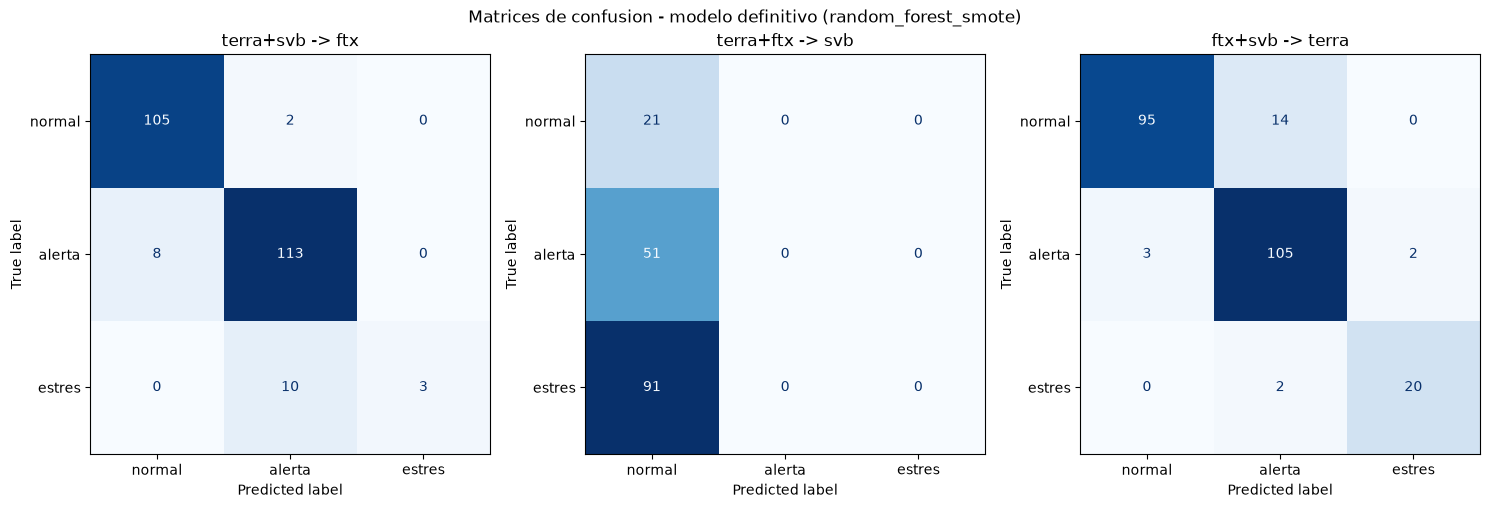

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

MODELO_DEFINITIVO = "random_forest_smote"
resultados_def = [r for r in resultados if r["candidato"] == MODELO_DEFINITIVO]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, r in zip(axes, resultados_def):
    cm = confusion_matrix(r["y_val"], r["y_pred"], labels=["normal", "alerta", "estres"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "alerta", "estres"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(r["combinacion"])

fig.suptitle(f"Matrices de confusion - modelo definitivo ({MODELO_DEFINITIVO})")
plt.tight_layout()
plt.savefig("../informe/fig_matrices_confusion_definitivo.png", dpi=150)
plt.show()